<a href="https://colab.research.google.com/github/Math-BUG/INF-494/blob/main/02_dbscan_nvcc_quantizacao_uint8_uint4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN CUDA C++/NVCC - Quantizacao uint8 e uint4 packed

Este notebook usa o protocolo comum de `data/manifest.csv` e compara `baseline_cuML` ou `baseline_sklearn`, `cuda_cpp_float32`, `cuda_cpp_uint8` e `cuda_cpp_uint4_packed`.

`uint8` tende a ser o melhor equilibrio quando reduz leitura de memoria com pouca perda de precisao. `uint4 packed` pode ser mais rapido, mas tem maior risco de degradar qualidade.

In [5]:
# Diagnostico do ambiente do Colab.
# Ative GPU em: Ambiente de execucao > Alterar tipo de ambiente de execucao > GPU.
!nvidia-smi
!nvcc --version
!which nvprof || echo "nvprof nao encontrado"

Mon Jun  8 06:11:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import os
import re
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)

# Use Google Drive para persistir data/ e results/ entre notebooks e runtimes do Colab.
# Se nao estiver no Colab, o codigo cai automaticamente para o diretorio local.
USE_GOOGLE_DRIVE = True
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/INF494_DBSCAN")

BASE_DIR = Path(".")
if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        BASE_DIR = DRIVE_PROJECT_DIR
    except Exception as exc:
        print("Google Drive nao montado; usando diretorio local.")
        print("Motivo:", repr(exc))
        BASE_DIR = Path(".")

DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

HAS_CUML = False
cp = None
CuMLDBSCAN = None

try:
    import cupy as cp
    from cuml.cluster import DBSCAN as CuMLDBSCAN
    HAS_CUML = True
    print("RAPIDS/cuML disponivel. Baseline: cuML.")
except Exception as exc:
    print("RAPIDS/cuML nao disponivel. Alternativa do baseline: sklearn CPU.")
    print("Motivo:", repr(exc))

print("HAS_CUML:", HAS_CUML)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/INF494_DBSCAN
DATA_DIR: /content/drive/MyDrive/INF494_DBSCAN/data
RESULTS_DIR: /content/drive/MyDrive/INF494_DBSCAN/results
RAPIDS/cuML disponivel. Baseline: cuML.
HAS_CUML: True


In [7]:
def normalize_minmax(X):
    X = np.asarray(X, dtype=np.float32)
    mn = X.min(axis=0)
    mx = X.max(axis=0)
    denom = mx - mn
    denom[denom == 0.0] = 1.0
    return ((X - mn) / denom).astype(np.float32)


def estimate_eps(X, min_samples=8, quantile=0.90, sample_size=5000, seed=SEED):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    if len(X) > sample_size:
        idx = rng.choice(len(X), size=sample_size, replace=False)
        Xs = X[idx]
    else:
        Xs = X
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(Xs)
    dists, _ = nn.kneighbors(Xs)
    return float(np.quantile(dists[:, -1], quantile))


def relabel_consecutive(labels):
    labels = np.asarray(labels, dtype=np.int32)
    out = np.full(labels.shape, -1, dtype=np.int32)
    valid = [int(v) for v in np.unique(labels) if int(v) != -1]
    for new, old in enumerate(sorted(valid)):
        out[labels == old] = new
    return out


def count_clusters(labels):
    values = set(np.asarray(labels).tolist())
    values.discard(-1)
    return len(values)


def noise_percent(labels):
    return 100.0 * float(np.mean(np.asarray(labels) == -1))


def run_baseline_dbscan(X, eps, min_samples):
    X = np.ascontiguousarray(X.astype(np.float32))
    start = time.time()
    if HAS_CUML:
        X_gpu = cp.asarray(X)
        model = CuMLDBSCAN(eps=float(eps), min_samples=int(min_samples))
        labels_gpu = model.fit_predict(X_gpu)
        cp.cuda.Stream.null.synchronize()
        labels = cp.asnumpy(labels_gpu).astype(np.int32)
        backend = "cuML"
    else:
        model = SklearnDBSCAN(eps=float(eps), min_samples=int(min_samples), n_jobs=-1)
        labels = model.fit_predict(X).astype(np.int32)
        backend = "sklearn_cpu"
    elapsed = time.time() - start
    return relabel_consecutive(labels), elapsed, backend


def parse_key_values_stdout(stdout):
    metrics = {}
    for key, value in re.findall(r"([A-Za-z0-9_]+)=([^\s]+)", stdout):
        clean = value.strip().rstrip(",")
        try:
            if re.fullmatch(r"[-+]?\d+", clean):
                metrics[key] = int(clean)
            else:
                metrics[key] = float(clean)
        except ValueError:
            metrics[key] = clean
    return metrics


def run_cuda_binary(cmd):
    start = time.time()
    completed = subprocess.run(cmd, check=True, capture_output=True, text=True)
    wall_time = time.time() - start
    return completed.stdout, wall_time


def print_table(df, title):
    print(title)
    print(df.where(pd.notna(df), "N/A").to_string(index=False))


def plot_2d(X, labels, title):
    if X.shape[1] == 2:
        X2 = X[:, :2]
        xlab, ylab = "x1", "x2"
    else:
        X2 = PCA(n_components=2, random_state=SEED).fit_transform(X)
        xlab, ylab = "PCA1", "PCA2"
    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=8, cmap="tab20", alpha=0.85, linewidths=0)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.tight_layout()
    plt.show()

def make_controlled_dataset(name, n_samples, seed=SEED, n_features_32d=32):
    rng = np.random.default_rng(seed)
    if name == "dense_blobs_2d":
        X, y = make_blobs(n_samples=n_samples, centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)], cluster_std=0.18, random_state=seed)
    elif name == "heterogeneous_blobs_2d":
        n1 = int(0.45 * n_samples)
        n2 = int(0.35 * n_samples)
        n3 = n_samples - n1 - n2
        X1, _ = make_blobs(n_samples=n1, centers=[(-4, 0)], cluster_std=0.08, random_state=seed + 1)
        X2, _ = make_blobs(n_samples=n2, centers=[(0, 0)], cluster_std=0.25, random_state=seed + 2)
        X3, _ = make_blobs(n_samples=n3, centers=[(4, 0)], cluster_std=0.65, random_state=seed + 3)
        X = np.vstack([X1, X2, X3])
        y = np.concatenate([np.zeros(n1, dtype=np.int32), np.ones(n2, dtype=np.int32), np.full(n3, 2, dtype=np.int32)])
    elif name == "dense_blobs_noise_2d":
        n_noise = int(0.20 * n_samples)
        n_blob = n_samples - n_noise
        X_blob, y_blob = make_blobs(n_samples=n_blob, centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)], cluster_std=0.20, random_state=seed)
        noise = rng.uniform(low=-5.5, high=5.5, size=(n_noise, 2))
        X = np.vstack([X_blob, noise])
        y = np.concatenate([y_blob.astype(np.int32), np.full(n_noise, -1, dtype=np.int32)])
    elif name == "moons_2d":
        X, y = make_moons(n_samples=n_samples, noise=0.045, random_state=seed)
    elif name == "blobs_32d":
        X, y = make_blobs(n_samples=n_samples, centers=6, n_features=n_features_32d, cluster_std=0.45, random_state=seed)
    else:
        raise ValueError(f"Fallback local so cobre datasets sinteticos. Dataset recebido: {name}")
    return normalize_minmax(X), np.asarray(y, dtype=np.int32)


def load_dataset_from_manifest(dataset_name, n_samples, run_mode="benchmark", allow_local_debug_fallback=True):
    manifest_path = DATA_DIR / "manifest.csv"
    if manifest_path.exists():
        manifest = pd.read_csv(manifest_path)
        rows = manifest[(manifest["dataset_name"] == dataset_name) & (manifest["n_samples"] == int(n_samples))]
        if rows.empty:
            available = manifest[["dataset_name", "n_samples"]].drop_duplicates().to_string(index=False)
            raise ValueError(
                f"Dataset {dataset_name} com n_samples={n_samples} nao esta no manifest. "
                f"Execute o notebook 00 ou escolha uma entrada existente.\nEntradas disponiveis:\n{available}"
            )
        row = rows.iloc[0].to_dict()
        data_path = Path(row["data_path"])
        label_path = Path(row["label_path"])
        if not data_path.exists() or not label_path.exists():
            raise FileNotFoundError(
                f"Arquivos do dataset nao encontrados: {data_path} / {label_path}. "
                "Execute primeiro o notebook 00_datasets_e_configuracao.ipynb no Colab."
            )
        n = int(row["n_samples"])
        d = int(row["n_features"])
        X = np.fromfile(data_path, dtype=np.float32).reshape(n, d)
        y_true = np.load(label_path).astype(np.int32)
        return {
            "X": np.ascontiguousarray(X),
            "y_true": y_true,
            "EPS": float(row["eps"]),
            "MIN_SAMPLES": int(row["min_samples"]),
            "INPUT_BIN": str(data_path),
            "N": n,
            "D": d,
            "metadata": row,
            "loaded_from_manifest": True,
        }

    message = (
        "data/manifest.csv nao encontrado. Execute primeiro o notebook "
        "00_datasets_e_configuracao.ipynb para gerar datasets comuns."
    )
    if not allow_local_debug_fallback:
        raise FileNotFoundError(message)
    print(message)
    print("Usando fallback local apenas para depuracao. Resultados finais devem usar o manifest comum.")
    fallback_n = 4000 if run_mode == "quick" else min(int(n_samples), 4000)
    X, y_true = make_controlled_dataset(dataset_name, fallback_n)
    X = np.ascontiguousarray(X.astype(np.float32))
    eps = estimate_eps(X, min_samples=8, quantile=0.90, sample_size=5000)
    input_bin = f"debug_{dataset_name}_{fallback_n}_f32.bin"
    X.tofile(input_bin)
    return {
        "X": X,
        "y_true": y_true,
        "EPS": eps,
        "MIN_SAMPLES": 8,
        "INPUT_BIN": input_bin,
        "N": int(X.shape[0]),
        "D": int(X.shape[1]),
        "metadata": {
            "dataset_name": dataset_name,
            "n_samples": int(X.shape[0]),
            "n_features": int(X.shape[1]),
            "tipo": "debug_local",
            "observacao": "Fallback local; nao usar em resultado final.",
        },
        "loaded_from_manifest": False,
    }

In [8]:
# Celula padrao de selecao do dataset comum.
# Primeiro teste: mantenha RUN_MODE="quick" e N_SAMPLES=4000, que e o padrao gerado pelo notebook 00.
# Para resultados finais: rode o notebook 00 em RUN_MODE="benchmark" e depois use N_SAMPLES=10000/25000/50000 aqui.
DATASET_NAME = "real_covtype_sample"
N_SAMPLES = 100000
RUN_MODE = "benchmark"  # use "benchmark" e N_SAMPLES = 10000 depois de gerar o manifest benchmark no notebook 00
ALLOW_LOCAL_DEBUG_FALLBACK = True

print("Datasets recomendados para este notebook:", ['blobs_32d', 'real_covtype_sample', 'real_higgs_sample'])

loaded = load_dataset_from_manifest(
    DATASET_NAME,
    N_SAMPLES,
    run_mode=RUN_MODE,
    allow_local_debug_fallback=ALLOW_LOCAL_DEBUG_FALLBACK,
)

X = loaded["X"]
y_true = loaded["y_true"]
EPS = loaded["EPS"]
MIN_SAMPLES = loaded["MIN_SAMPLES"]
INPUT_BIN = loaded["INPUT_BIN"]
N = loaded["N"]
D = loaded["D"]
META = loaded["metadata"]

print("Dataset ativo:", DATASET_NAME)
print("Carregado do manifest:", loaded["loaded_from_manifest"])
print("Shape:", X.shape)
print("eps:", EPS)
print("min_samples:", MIN_SAMPLES)
print("INPUT_BIN:", INPUT_BIN)

Datasets recomendados para este notebook: ['blobs_32d', 'real_covtype_sample', 'real_higgs_sample']
Dataset ativo: real_covtype_sample
Carregado do manifest: True
Shape: (100000, 54)
eps: 0.402961590886116
min_samples: 8
INPUT_BIN: /content/drive/MyDrive/INF494_DBSCAN/data/real_covtype_sample_100000_f32.bin


In [9]:
%%writefile dbscan_quantized.cu
#include <stdio.h>
#include <stdlib.h>
#include <stdint.h>
#include <math.h>
#include <fstream>
#include <vector>
#include <string>

#define CUDA_CHECK(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

__device__ int find_root(int* parent, int i) {
    int root = i;
    while (root != parent[root]) root = parent[root];
    return root;
}

__global__ void init_parent_labels(const int* is_core, int* parent, int* keep_core, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    parent[i] = i;
    keep_core[i] = is_core[i];
}

__global__ void flatten_parents(int* parent, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int root = i;
    while (root != parent[root]) root = parent[root];
    parent[i] = root;
}


__global__ void count_core_f32(const float* X, int* is_core, int n, int d, float eps_sq, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int count = 0;
    for (int j = 0; j < n; j++) {
        float dist2 = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i*d + f] - X[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps_sq) break;
        }
        if (dist2 <= eps_sq) {
            count++;
            if (count >= min_pts) break;
        }
    }
    is_core[i] = (count >= min_pts) ? 1 : 0;
}

__global__ void connect_f32(const float* X, const int* keep_core, int* parent, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;
    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;
        float dist2 = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i*d + f] - X[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps_sq) break;
        }
        if (dist2 <= eps_sq) {
            int ri = find_root(parent, i);
            int rj = find_root(parent, j);
            while (ri != rj) {
                if (ri < rj) {
                    int old = atomicCAS(&parent[rj], rj, ri);
                    if (old == rj) break;
                    rj = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[ri], ri, rj);
                    if (old == ri) break;
                    ri = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void assign_f32(const float* X, const int* keep_core, const int* parent, int* labels, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }
    int best = -1;
    float best_d = eps_sq;
    int found = 0;
    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;
        float dist2 = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i*d + f] - X[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps_sq) break;
        }
        if (dist2 <= eps_sq && (!found || dist2 < best_d)) {
            found = 1;
            best_d = dist2;
            best = parent[j];
        }
    }
    labels[i] = best;
}

__global__ void count_core_u8(const uint8_t* Q, int* is_core, int n, int d, int eps2_q, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int count = 0;
    for (int j = 0; j < n; j++) {
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = (int)Q[i*d + f] - (int)Q[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q) {
            count++;
            if (count >= min_pts) break;
        }
    }
    is_core[i] = (count >= min_pts) ? 1 : 0;
}

__global__ void connect_u8(const uint8_t* Q, const int* keep_core, int* parent, int n, int d, int eps2_q) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;
    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = (int)Q[i*d + f] - (int)Q[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q) {
            int ri = find_root(parent, i);
            int rj = find_root(parent, j);
            while (ri != rj) {
                if (ri < rj) {
                    int old = atomicCAS(&parent[rj], rj, ri);
                    if (old == rj) break;
                    rj = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[ri], ri, rj);
                    if (old == ri) break;
                    ri = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void assign_u8(const uint8_t* Q, const int* keep_core, const int* parent, int* labels, int n, int d, int eps2_q) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }
    int best = -1;
    int best_d = eps2_q;
    int found = 0;
    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = (int)Q[i*d + f] - (int)Q[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q && (!found || dist2 < best_d)) {
            found = 1;
            best_d = dist2;
            best = parent[j];
        }
    }
    labels[i] = best;
}

__device__ int get_u4(const uint8_t* P, int i, int k, int packed_d) {
    uint8_t byte = P[i * packed_d + (k / 2)];
    if ((k & 1) == 0) return (int)(byte & 0x0F);
    return (int)((byte >> 4) & 0x0F);
}

__global__ void count_core_u4(const uint8_t* P, int* is_core, int n, int d, int packed_d, int eps2_q, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int count = 0;
    for (int j = 0; j < n; j++) {
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = get_u4(P, i, f, packed_d) - get_u4(P, j, f, packed_d);
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q) {
            count++;
            if (count >= min_pts) break;
        }
    }
    is_core[i] = (count >= min_pts) ? 1 : 0;
}

__global__ void connect_u4(const uint8_t* P, const int* keep_core, int* parent, int n, int d, int packed_d, int eps2_q) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;
    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = get_u4(P, i, f, packed_d) - get_u4(P, j, f, packed_d);
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q) {
            int ri = find_root(parent, i);
            int rj = find_root(parent, j);
            while (ri != rj) {
                if (ri < rj) {
                    int old = atomicCAS(&parent[rj], rj, ri);
                    if (old == rj) break;
                    rj = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[ri], ri, rj);
                    if (old == ri) break;
                    ri = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void assign_u4(const uint8_t* P, const int* keep_core, const int* parent, int* labels, int n, int d, int packed_d, int eps2_q) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }
    int best = -1;
    int best_d = eps2_q;
    int found = 0;
    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = get_u4(P, i, f, packed_d) - get_u4(P, j, f, packed_d);
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q && (!found || dist2 < best_d)) {
            found = 1;
            best_d = dist2;
            best = parent[j];
        }
    }
    labels[i] = best;
}

int main(int argc, char** argv) {
    if (argc < 8) {
        printf("Usage: %s input.bin output_labels.bin n d eps min_pts mode[f32|u8|u4]\n", argv[0]);
        return 1;
    }
    std::string input_path = argv[1];
    std::string output_path = argv[2];
    int n = atoi(argv[3]);
    int d = atoi(argv[4]);
    float eps = (float)atof(argv[5]);
    int min_pts = atoi(argv[6]);
    std::string mode = argv[7];

    size_t count = (size_t)n * (size_t)d;
    std::vector<float> h_X(count);
    std::ifstream in(input_path, std::ios::binary);
    if (!in) { printf("Could not open input.\n"); return 1; }
    in.read((char*)h_X.data(), count * sizeof(float));
    in.close();

    int threads = 256;
    int blocks = (n + threads - 1) / threads;
    int *d_is_core = nullptr, *d_parent = nullptr, *d_keep = nullptr, *d_labels = nullptr;
    CUDA_CHECK(cudaMalloc(&d_is_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_parent, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_keep, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_labels, n * sizeof(int)));

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);

    int eps2_q = 0;
    if (mode == "f32") {
        eps2_q = -1;
        float eps_sq = eps * eps;
        float* d_X = nullptr;
        CUDA_CHECK(cudaMalloc(&d_X, count * sizeof(float)));
        CUDA_CHECK(cudaMemcpy(d_X, h_X.data(), count * sizeof(float), cudaMemcpyHostToDevice));
        count_core_f32<<<blocks, threads>>>(d_X, d_is_core, n, d, eps_sq, min_pts);
        CUDA_CHECK(cudaDeviceSynchronize());
        init_parent_labels<<<blocks, threads>>>(d_is_core, d_parent, d_keep, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        connect_f32<<<blocks, threads>>>(d_X, d_keep, d_parent, n, d, eps_sq);
        CUDA_CHECK(cudaDeviceSynchronize());
        flatten_parents<<<blocks, threads>>>(d_parent, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        assign_f32<<<blocks, threads>>>(d_X, d_keep, d_parent, d_labels, n, d, eps_sq);
        CUDA_CHECK(cudaDeviceSynchronize());
        cudaFree(d_X);
    } else if (mode == "u8") {
        std::vector<uint8_t> h_Q(count);
        for (size_t i = 0; i < count; i++) {
            float v = h_X[i];
            if (v < 0.0f) v = 0.0f;
            if (v > 1.0f) v = 1.0f;
            h_Q[i] = (uint8_t)lrintf(v * 255.0f);
        }
        eps2_q = (int)ceilf((eps * 255.0f) * (eps * 255.0f));
        uint8_t* d_Q = nullptr;
        CUDA_CHECK(cudaMalloc(&d_Q, count * sizeof(uint8_t)));
        CUDA_CHECK(cudaMemcpy(d_Q, h_Q.data(), count * sizeof(uint8_t), cudaMemcpyHostToDevice));
        count_core_u8<<<blocks, threads>>>(d_Q, d_is_core, n, d, eps2_q, min_pts);
        CUDA_CHECK(cudaDeviceSynchronize());
        init_parent_labels<<<blocks, threads>>>(d_is_core, d_parent, d_keep, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        connect_u8<<<blocks, threads>>>(d_Q, d_keep, d_parent, n, d, eps2_q);
        CUDA_CHECK(cudaDeviceSynchronize());
        flatten_parents<<<blocks, threads>>>(d_parent, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        assign_u8<<<blocks, threads>>>(d_Q, d_keep, d_parent, d_labels, n, d, eps2_q);
        CUDA_CHECK(cudaDeviceSynchronize());
        cudaFree(d_Q);
    } else if (mode == "u4") {
        int packed_d = (d + 1) / 2;
        std::vector<uint8_t> h_P((size_t)n * (size_t)packed_d, 0);
        for (int i = 0; i < n; i++) {
            for (int f = 0; f < d; f++) {
                float v = h_X[(size_t)i * d + f];
                if (v < 0.0f) v = 0.0f;
                if (v > 1.0f) v = 1.0f;
                uint8_t q = (uint8_t)lrintf(v * 15.0f);
                int byte_idx = i * packed_d + (f / 2);
                if ((f & 1) == 0) h_P[byte_idx] |= (q & 0x0F);
                else h_P[byte_idx] |= (q & 0x0F) << 4;
            }
        }
        eps2_q = (int)ceilf((eps * 15.0f) * (eps * 15.0f));
        uint8_t* d_P = nullptr;
        CUDA_CHECK(cudaMalloc(&d_P, h_P.size() * sizeof(uint8_t)));
        CUDA_CHECK(cudaMemcpy(d_P, h_P.data(), h_P.size() * sizeof(uint8_t), cudaMemcpyHostToDevice));
        count_core_u4<<<blocks, threads>>>(d_P, d_is_core, n, d, packed_d, eps2_q, min_pts);
        CUDA_CHECK(cudaDeviceSynchronize());
        init_parent_labels<<<blocks, threads>>>(d_is_core, d_parent, d_keep, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        connect_u4<<<blocks, threads>>>(d_P, d_keep, d_parent, n, d, packed_d, eps2_q);
        CUDA_CHECK(cudaDeviceSynchronize());
        flatten_parents<<<blocks, threads>>>(d_parent, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        assign_u4<<<blocks, threads>>>(d_P, d_keep, d_parent, d_labels, n, d, packed_d, eps2_q);
        CUDA_CHECK(cudaDeviceSynchronize());
        cudaFree(d_P);
    } else {
        printf("Unknown mode: %s\n", mode.c_str());
        return 1;
    }

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float ms = 0.0f;
    cudaEventElapsedTime(&ms, start, stop);

    std::vector<int> h_labels(n), h_core(n);
    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_core.data(), d_is_core, n * sizeof(int), cudaMemcpyDeviceToHost));

    int n_core = 0, n_noise = 0;
    for (int i = 0; i < n; i++) {
        n_core += h_core[i];
        if (h_labels[i] == -1) n_noise++;
    }

    std::ofstream out(output_path, std::ios::binary);
    out.write((char*)h_labels.data(), n * sizeof(int));
    out.close();

    printf("mode=%s n=%d d=%d eps=%f min_pts=%d eps2_q=%d core_points=%d noise=%d total=%.6f seconds\n",
           mode.c_str(), n, d, eps, min_pts, eps2_q, n_core, n_noise, ms / 1000.0f);

    cudaFree(d_is_core); cudaFree(d_parent); cudaFree(d_keep); cudaFree(d_labels);
    return 0;
}

Writing dbscan_quantized.cu


In [10]:
!nvcc dbscan_quantized.cu -o dbscan_quantized -O3

!if command -v nvprof >/dev/null 2>&1; then nvprof ./dbscan_quantized {INPUT_BIN} nvprof_float32_labels.bin {N} {D} {EPS} {MIN_SAMPLES} f32; else echo "nvprof nao encontrado; executando binario diretamente"; ./dbscan_quantized {INPUT_BIN} nvprof_float32_labels.bin {N} {D} {EPS} {MIN_SAMPLES} f32; fi

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
==2162== NVPROF is profiling process 2162, command: ./dbscan_quantized /content/drive/MyDrive/INF494_DBSCAN/data/real_covtype_sample_100000_f32.bin nvprof_float32_labels.bin 100000 54 0.402961590886116 8 f32
mode=f32 n=100000 d=54 eps=0.402962 min_pts=8 eps2_q=-1 core_points=99869 noise=44 total=3.627363 seconds
==2162== Profiling application: ./dbscan_quantized /content/drive/MyDrive/INF494_DBSCAN/data/real_covtype_sample_100000_f32.bin nvprof_float32_labels.bin 100000 54 0.402961590886116 8 f32
==2162== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   89.89%  3.10585s         1  3.10585s  3.10585s  3.10585s  connect_f32(float const *, int const *, int*, int, int, float)
                    7.66%  264.67ms         1  264.67ms  264.6

In [11]:
labels_baseline, time_baseline, backend = run_baseline_dbscan(X, EPS, MIN_SAMPLES)
baseline_version = f"baseline_{backend}"
PACKED_D = (D + 1) // 2

cuda_runs = [
    ("cuda_cpp_float32", "f32", 4.0, D),
    ("cuda_cpp_uint8", "u8", 1.0, D),
    ("cuda_cpp_uint4_packed", "u4", 0.5, PACKED_D),
]

cuda_rows = []
all_labels = {baseline_version: labels_baseline}
labels_cuda_float32 = None
float32_event_time = np.nan

for version, mode, bytes_attr, packed_d in cuda_runs:
    out_file = f"{DATASET_NAME}_{N}_{version}_labels.bin"
    cmd = ["./dbscan_quantized", INPUT_BIN, out_file, str(N), str(D), str(EPS), str(MIN_SAMPLES), mode]
    stdout, wall_time = run_cuda_binary(cmd)
    print("\n---", version, "---")
    print(stdout)
    metrics = parse_key_values_stdout(stdout)
    labels = relabel_consecutive(np.fromfile(out_file, dtype=np.int32, count=N))
    all_labels[version] = labels
    if mode == "f32":
        labels_cuda_float32 = labels.copy()
        float32_event_time = float(metrics.get("total", np.nan))
    cuda_rows.append({
        "dataset_name": DATASET_NAME,
        "n_samples": N,
        "n_features": D,
        "versao": version,
        "modo": str(metrics.get("mode", mode)),
        "bytes_por_atributo_aprox": bytes_attr,
        "dimensao_original": D,
        "dimensao_empacotada": packed_d,
        "core_points": int(metrics.get("core_points", 0)),
        "noise": int(metrics.get("noise", np.sum(labels == -1))),
        "noise_%": noise_percent(labels),
        "time_s_wall": wall_time,
        "total_cuda_event_s": float(metrics.get("total", np.nan)),
        "speedup_vs_cuda_float32_event": np.nan,
        "speedup_vs_baseline_wall": time_baseline / wall_time if wall_time > 0 else np.nan,
        "clusters": count_clusters(labels),
        "ARI_vs_baseline": adjusted_rand_score(labels_baseline, labels),
        "NMI_vs_baseline": normalized_mutual_info_score(labels_baseline, labels),
        "ARI_vs_cuda_float32": np.nan,
        "NMI_vs_cuda_float32": np.nan,
        "eps2_q": int(metrics.get("eps2_q", -1)),
    })

for row in cuda_rows:
    labels = all_labels[row["versao"]]
    row["ARI_vs_cuda_float32"] = adjusted_rand_score(labels_cuda_float32, labels)
    row["NMI_vs_cuda_float32"] = normalized_mutual_info_score(labels_cuda_float32, labels)
    event_time = row["total_cuda_event_s"]
    if pd.notna(float32_event_time) and pd.notna(event_time) and event_time > 0:
        row["speedup_vs_cuda_float32_event"] = float32_event_time / event_time

baseline_row = {
    "dataset_name": DATASET_NAME,
    "n_samples": N,
    "n_features": D,
    "versao": baseline_version,
    "modo": "baseline",
    "bytes_por_atributo_aprox": 4.0,
    "dimensao_original": D,
    "dimensao_empacotada": np.nan,
    "core_points": np.nan,
    "noise": int(np.sum(labels_baseline == -1)),
    "noise_%": noise_percent(labels_baseline),
    "time_s_wall": time_baseline,
    "total_cuda_event_s": np.nan,
    "speedup_vs_cuda_float32_event": np.nan,
    "speedup_vs_baseline_wall": 1.0,
    "clusters": count_clusters(labels_baseline),
    "ARI_vs_baseline": 1.0,
    "NMI_vs_baseline": 1.0,
    "ARI_vs_cuda_float32": adjusted_rand_score(labels_cuda_float32, labels_baseline),
    "NMI_vs_cuda_float32": normalized_mutual_info_score(labels_cuda_float32, labels_baseline),
    "eps2_q": np.nan,
}

df_results = pd.DataFrame([baseline_row] + cuda_rows)
output_csv = RESULTS_DIR / f"resultados_quantizacao_{DATASET_NAME}_{N}.csv"
df_results.to_csv(output_csv, index=False)
print_table(df_results.round(4), "Tabela final - quantizacao")
print("CSV salvo em:", output_csv)

[2026-06-08 06:12:06.500] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 24974 -> 21474. Using the larger integer type might result in better performance

--- cuda_cpp_float32 ---
mode=f32 n=100000 d=54 eps=0.402962 min_pts=8 eps2_q=-1 core_points=99869 noise=44 total=3.367659 seconds


--- cuda_cpp_uint8 ---
mode=u8 n=100000 d=54 eps=0.402962 min_pts=8 eps2_q=10559 core_points=99870 noise=44 total=1.154806 seconds


--- cuda_cpp_uint4_packed ---
mode=u4 n=100000 d=54 eps=0.402962 min_pts=8 eps2_q=37 core_points=99871 noise=46 total=1.059652 seconds

Tabela final - quantizacao
       dataset_name  n_samples  n_features                versao     modo  bytes_por_atributo_aprox  dimensao_original dimensao_empacotada core_points  noise  noise_%  time_s_wall total_cuda_event_s speedup_vs_cuda_float32_event  speedup_vs_baseline_wall  clusters  ARI_vs_baseline  NMI_vs_baseline  ARI_vs_cuda_float32  NMI_vs_cuda_float32   eps2_q
real_covtype_sample     100000          54

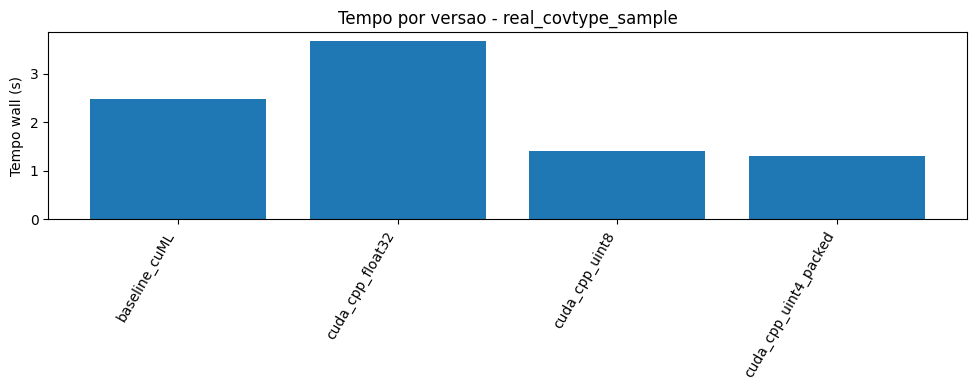

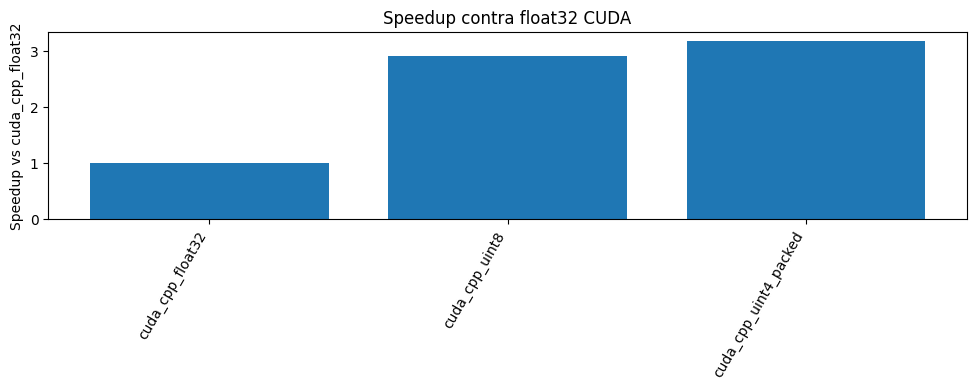

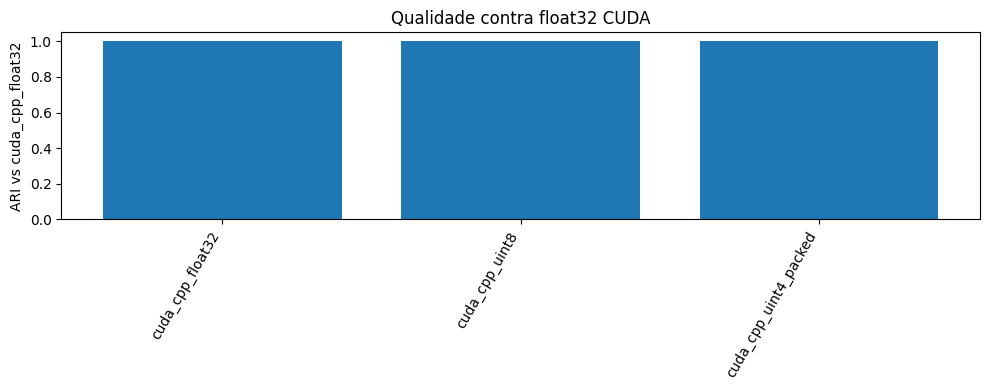

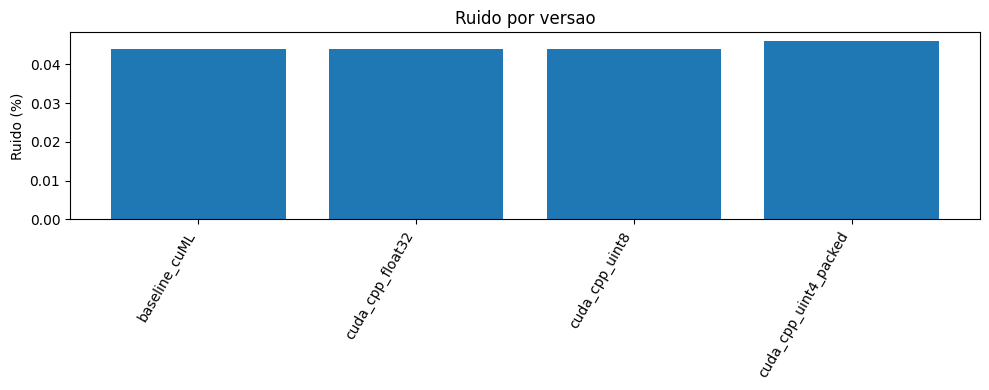

In [12]:
df_cuda = df_results[df_results["versao"].str.startswith("cuda_cpp")].copy()

plt.figure(figsize=(10, 4))
plt.bar(df_results["versao"], df_results["time_s_wall"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Tempo wall (s)")
plt.title(f"Tempo por versao - {DATASET_NAME}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(df_cuda["versao"], df_cuda["speedup_vs_cuda_float32_event"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Speedup vs cuda_cpp_float32")
plt.title("Speedup contra float32 CUDA")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(df_cuda["versao"], df_cuda["ARI_vs_cuda_float32"])
plt.xticks(rotation=60, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("ARI vs cuda_cpp_float32")
plt.title("Qualidade contra float32 CUDA")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(df_results["versao"], df_results["noise_%"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Ruido (%)")
plt.title("Ruido por versao")
plt.tight_layout()
plt.show()